In [16]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
df = pd.read_csv("intern_performance_dataset.csv")

df.head()

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate,Performance_Status
0,362,83.810694,15.0,7.014365,5.021973,63.156155,3.932205,NaN,13.0,11.0,0.73,Successful
1,74,97.231921,25.0,8.236330,8.210449,79.106645,1.785343,37.436140,17.0,22.0,0.88,Successful
2,375,72.421732,16.0,7.259562,5.589526,51.345607,4.748364,18.757585,15.0,11.0,0.69,Successful
3,156,88.630829,23.0,9.492090,7.727412,NaN,0.869655,32.021426,14.0,19.0,0.83,Successful
4,105,98.613497,21.0,9.900124,7.227590,82.793052,0.036781,30.693287,14.0,20.0,0.95,Successful


In [19]:
df.head(10)

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate,Performance_Status
0,362,83.810694,15.0,7.014365,5.021973,63.156155,3.932205,NaN,13.0,11.0,0.73,Successful
1,74,97.231921,25.0,8.236330,8.210449,79.106645,1.785343,37.436140,17.0,22.0,0.88,Successful
2,375,72.421732,16.0,7.259562,5.589526,51.345607,4.748364,18.757585,15.0,11.0,0.69,Successful
3,156,88.630829,23.0,9.492090,7.727412,NaN,0.869655,32.021426,14.0,19.0,0.83,Successful
4,105,98.613497,21.0,9.900124,7.227590,82.793052,0.036781,30.693287,14.0,20.0,0.95,Successful
5,395,87.855913,21.0,6.301402,4.675417,57.700827,1.451727,26.962955,12.0,16.0,0.76,Successful
6,378,80.755219,21.0,7.183842,4.782437,54.956118,NaN,30.938501,11.0,14.0,0.67,Successful
7,125,88.419027,30.0,9.523021,7.619001,88.568111,1.037835,33.950509,19.0,26.0,0.87,Successful
8,69,86.118260,22.0,8.637951,8.560491,96.045719,0.415773,NaN,16.0,21.0,0.95,Successful
9,451,61.429799,18.0,2.993505,4.593698,54.134839,5.088164,9.207593,5.0,9.0,0.50,Needs Improvement


In [20]:
df.tail()

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate,Performance_Status
495,107,91.155744,29.0,9.146876,7.384138,93.598657,0.235502,34.443693,18.0,25.0,0.86,Successful
496,271,79.485372,19.0,6.938270,6.524683,74.781172,1.606337,32.785974,15.0,15.0,0.79,Successful
497,349,84.887759,21.0,5.332424,5.423893,NaN,NaN,28.958050,14.0,15.0,0.71,Successful
498,436,57.513183,13.0,3.736084,5.294084,39.634865,5.939753,8.510442,8.0,7.0,0.54,Needs Improvement
499,103,89.715340,20.0,8.182573,8.900203,94.714930,0.343359,29.846751,NaN,19.0,0.95,Successful


In [21]:
df.shape

(500, 12)

In [22]:
len(df)

500

In [23]:
df.columns

Index(['Intern_ID', 'Attendance_Percentage', 'Tasks_Assigned',
       'Feedback_Score', 'Participation_Score', 'Learning_Assessment_Score',
       'Avg_Submission_Delay_Days', 'Weekly_Activity_Hours',
       'Meetings_Attended', 'Tasks_Completed', 'Task_Completion_Rate',
       'Performance_Status'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Intern_ID                  500 non-null    int64  
 1   Attendance_Percentage      484 non-null    float64
 2   Tasks_Assigned             491 non-null    float64
 3   Feedback_Score             485 non-null    float64
 4   Participation_Score        492 non-null    float64
 5   Learning_Assessment_Score  487 non-null    float64
 6   Avg_Submission_Delay_Days  487 non-null    float64
 7   Weekly_Activity_Hours      491 non-null    float64
 8   Meetings_Attended          487 non-null    float64
 9   Tasks_Completed            486 non-null    float64
 10  Task_Completion_Rate       487 non-null    float64
 11  Performance_Status         500 non-null    object 
dtypes: float64(10), int64(1), object(1)
memory usage: 47.0+ KB


In [25]:
df.describe()

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate
count,500.000000,484.000000,491.000000,485.000000,492.000000,487.000000,487.000000,491.000000,487.000000,486.000000,487.000000
mean,250.500000,78.527892,20.535642,6.854272,6.305210,69.245297,3.244127,27.454955,11.944559,15.969136,0.751191
std,144.481833,14.528546,4.683041,2.019204,2.178449,17.725703,2.878466,7.944160,5.036799,6.062652,0.155931
min,1.000000,35.188946,10.000000,2.033280,1.009961,30.159404,0.021992,8.325463,0.000000,4.000000,0.360000
25%,125.750000,68.999570,17.000000,5.454708,4.722330,54.648290,1.177881,21.901411,9.000000,12.000000,0.650000
50%,250.500000,81.145633,21.000000,6.887896,6.654460,71.527164,2.481588,29.011124,12.000000,16.000000,0.760000
75%,375.250000,89.395792,24.000000,8.586422,7.913736,83.355060,4.311665,33.455282,16.000000,20.000000,0.880000
max,500.000000,99.803304,30.000000,9.985930,9.999153,99.749006,11.990034,39.975209,20.000000,29.000000,1.000000


In [26]:
df.sample(5, random_state=42)

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate,Performance_Status
361,293,71.313195,25.0,7.343511,7.379158,51.934738,1.602086,29.696756,11.0,18.0,0.72,Successful
73,291,79.697109,23.0,7.790957,5.484828,71.907384,3.331938,27.244697,11.0,18.0,0.78,Successful
374,289,68.643914,20.0,5.229251,7.148506,52.227226,3.179311,31.996260,9.0,13.0,0.65,Successful
155,358,80.123848,19.0,7.027947,4.071783,74.999512,3.530176,22.696035,15.0,14.0,0.74,Successful
104,333,69.059547,16.0,5.766240,7.166800,73.602510,3.902866,28.304492,10.0,12.0,0.75,Successful


In [27]:
df.isnull().sum()

Intern_ID                     0
Attendance_Percentage        16
Tasks_Assigned                9
Feedback_Score               15
Participation_Score           8
Learning_Assessment_Score    13
Avg_Submission_Delay_Days    13
Weekly_Activity_Hours         9
Meetings_Attended            13
Tasks_Completed              14
Task_Completion_Rate         13
Performance_Status            0
dtype: int64

In [28]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [29]:
df.isnull().sum()

Intern_ID                    0
Attendance_Percentage        0
Tasks_Assigned               0
Feedback_Score               0
Participation_Score          0
Learning_Assessment_Score    0
Avg_Submission_Delay_Days    0
Weekly_Activity_Hours        0
Meetings_Attended            0
Tasks_Completed              0
Task_Completion_Rate         0
Performance_Status           0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
float_columns = df.select_dtypes(include=['float64']).columns
df[float_columns] = df[float_columns].round(2)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Intern_ID                  500 non-null    int64  
 1   Attendance_Percentage      500 non-null    float64
 2   Tasks_Assigned             500 non-null    float64
 3   Feedback_Score             500 non-null    float64
 4   Participation_Score        500 non-null    float64
 5   Learning_Assessment_Score  500 non-null    float64
 6   Avg_Submission_Delay_Days  500 non-null    float64
 7   Weekly_Activity_Hours      500 non-null    float64
 8   Meetings_Attended          500 non-null    float64
 9   Tasks_Completed            500 non-null    float64
 10  Task_Completion_Rate       500 non-null    float64
 11  Performance_Status         500 non-null    object 
dtypes: float64(10), int64(1), object(1)
memory usage: 47.0+ KB


In [33]:
df.head()

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate,Performance_Status
0,362,83.81,15.0,7.01,5.02,63.16,3.93,27.45,13.0,11.0,0.73,Successful
1,74,97.23,25.0,8.24,8.21,79.11,1.79,37.44,17.0,22.0,0.88,Successful
2,375,72.42,16.0,7.26,5.59,51.35,4.75,18.76,15.0,11.0,0.69,Successful
3,156,88.63,23.0,9.49,7.73,69.25,0.87,32.02,14.0,19.0,0.83,Successful
4,105,98.61,21.0,9.90,7.23,82.79,0.04,30.69,14.0,20.0,0.95,Successful


In [34]:
df.to_csv("intern_performance_dataset_cleaned.csv", index=False)

In [35]:
df['Performance_Status'].value_counts()

Performance_Status
Successful           347
Needs Improvement    153
Name: count, dtype: int64

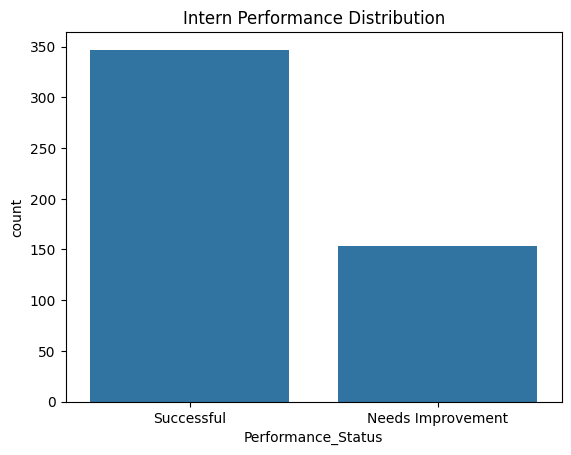

In [36]:
sns.countplot(x='Performance_Status', data=df)
plt.title('Intern Performance Distribution')
plt.show()

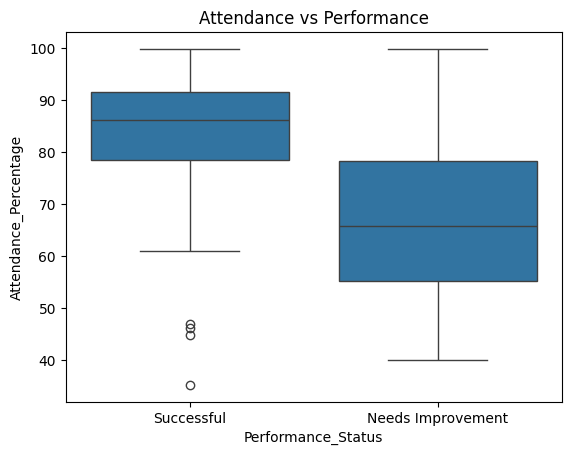

In [37]:
sns.boxplot(x='Performance_Status', y='Attendance_Percentage', data=df)
plt.title('Attendance vs Performance')
plt.show()

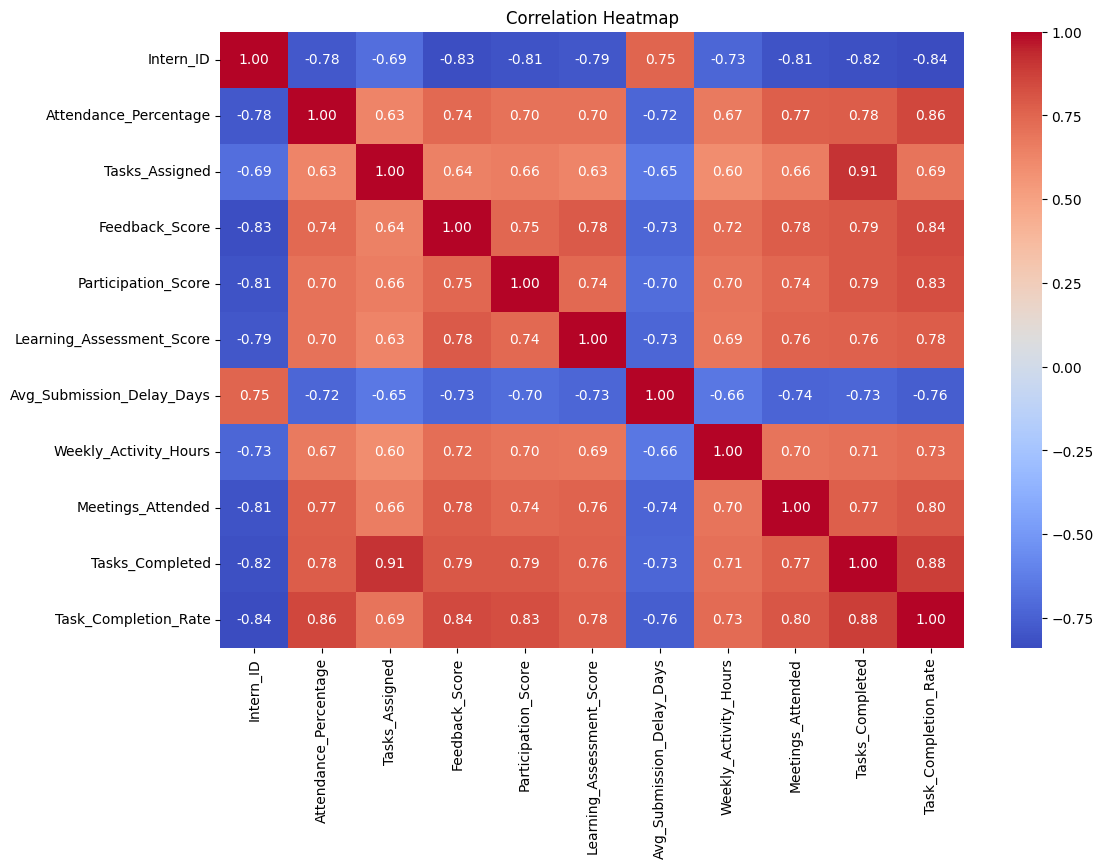

In [38]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

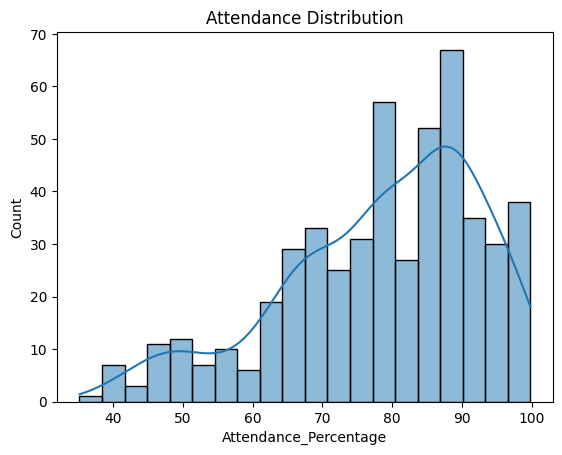

In [39]:
sns.histplot(df['Attendance_Percentage'], bins=20, kde=True)
plt.title('Attendance Distribution')
plt.show()

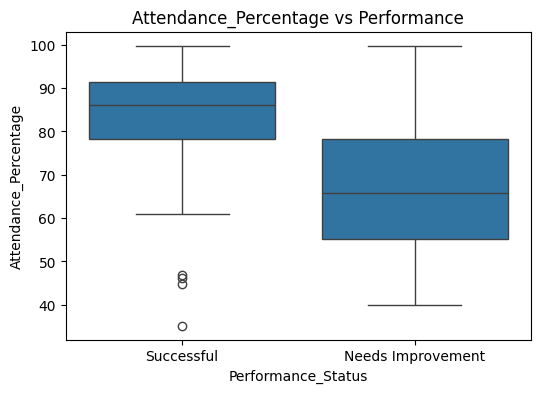

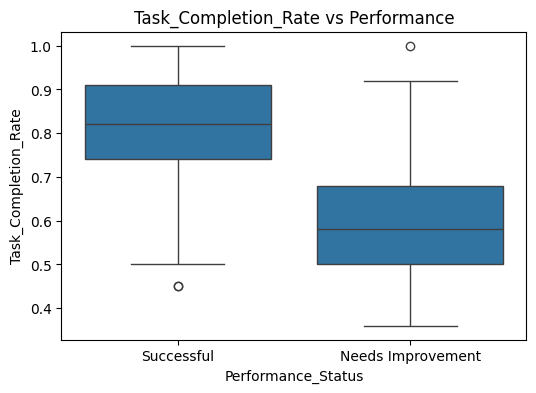

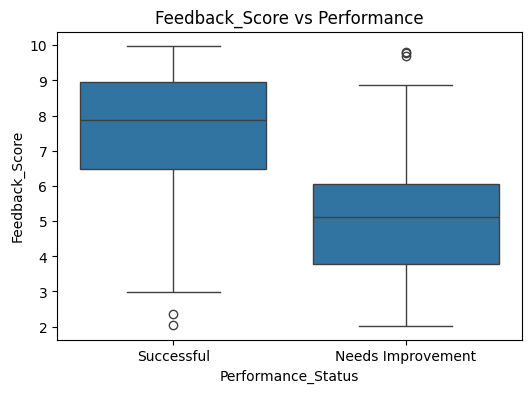

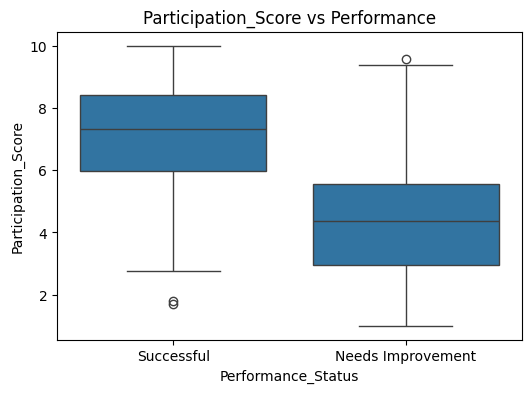

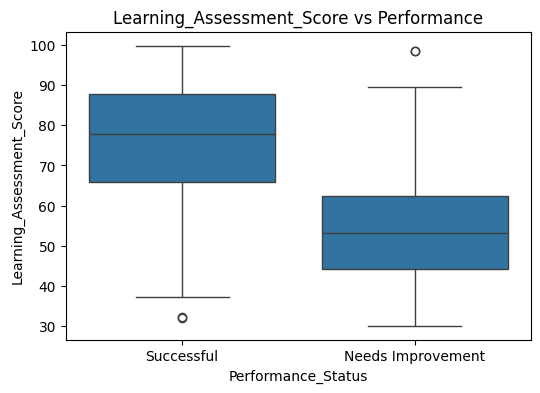

In [40]:
features = ['Attendance_Percentage', 'Task_Completion_Rate', 'Feedback_Score', 'Participation_Score', 'Learning_Assessment_Score']
for feature in features:    
    plt.figure(figsize=(6,4))    
    sns.boxplot(x='Performance_Status', y=feature, data=df)    
    plt.title(f'{feature} vs Performance')    
    plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [42]:
df["Performance_Status"] = le.fit_transform(df["Performance_Status"])

In [43]:
df.head()

,Intern_ID,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate,Performance_Status
0,362,83.81,15.0,7.01,5.02,63.16,3.93,27.45,13.0,11.0,0.73,1
1,74,97.23,25.0,8.24,8.21,79.11,1.79,37.44,17.0,22.0,0.88,1
2,375,72.42,16.0,7.26,5.59,51.35,4.75,18.76,15.0,11.0,0.69,1
3,156,88.63,23.0,9.49,7.73,69.25,0.87,32.02,14.0,19.0,0.83,1
4,105,98.61,21.0,9.90,7.23,82.79,0.04,30.69,14.0,20.0,0.95,1


In [44]:
print("Label Mapping:")
for index, label in enumerate(le.classes_):
    print(f"{label} → {index}")

Label Mapping:
Needs Improvement → 0
Successful → 1


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Intern_ID                  500 non-null    int64  
 1   Attendance_Percentage      500 non-null    float64
 2   Tasks_Assigned             500 non-null    float64
 3   Feedback_Score             500 non-null    float64
 4   Participation_Score        500 non-null    float64
 5   Learning_Assessment_Score  500 non-null    float64
 6   Avg_Submission_Delay_Days  500 non-null    float64
 7   Weekly_Activity_Hours      500 non-null    float64
 8   Meetings_Attended          500 non-null    float64
 9   Tasks_Completed            500 non-null    float64
 10  Task_Completion_Rate       500 non-null    float64
 11  Performance_Status         500 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 47.0 KB


In [46]:
X = df.drop(
    columns=[
        "Intern_ID",
        "Performance_Status"
    ]
)

In [47]:
y = df["Performance_Status"]

In [49]:
X.head()

,Attendance_Percentage,Tasks_Assigned,Feedback_Score,Participation_Score,Learning_Assessment_Score,Avg_Submission_Delay_Days,Weekly_Activity_Hours,Meetings_Attended,Tasks_Completed,Task_Completion_Rate
0,83.81,15.0,7.01,5.02,63.16,3.93,27.45,13.0,11.0,0.73
1,97.23,25.0,8.24,8.21,79.11,1.79,37.44,17.0,22.0,0.88
2,72.42,16.0,7.26,5.59,51.35,4.75,18.76,15.0,11.0,0.69
3,88.63,23.0,9.49,7.73,69.25,0.87,32.02,14.0,19.0,0.83
4,98.61,21.0,9.90,7.23,82.79,0.04,30.69,14.0,20.0,0.95


In [50]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Performance_Status, dtype: int64

In [51]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (500, 10)
Shape of y: (500,)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (400, 10)
X_test Shape : (100, 10)
y_train Shape: (400,)
y_test Shape : (100,)


In [54]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [55]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [56]:
print(model)

RandomForestClassifier(random_state=42)


In [57]:
y_pred = model.predict(X_test)

In [58]:
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[1 0 1 0 0 1 1 0 1 1]


In [59]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,1,0
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [60]:
correct = (comparison["Actual"] == comparison["Predicted"]).sum()
print("Correct Predictions:", correct," Out of 100")

Correct Predictions: 84  Out of 100


In [61]:
comparison[comparison["Actual"] != comparison["Predicted"]]

,Actual,Predicted
1,1,0
12,0,1
13,1,0
26,0,1
36,0,1
42,0,1
46,1,0
51,0,1
55,0,1
56,0,1


In [62]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 84.00%


In [63]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[20 11]
 [ 5 64]]


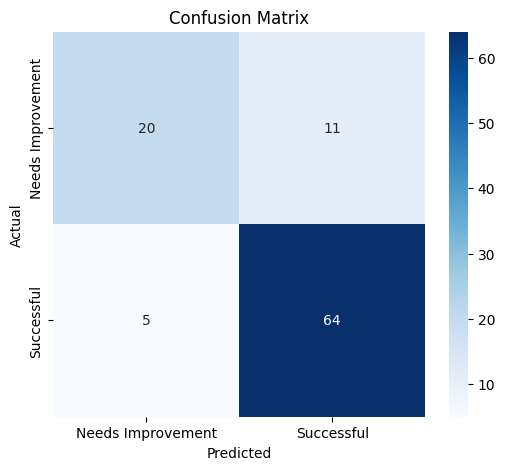

In [64]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Needs Improvement", "Successful"],
    yticklabels=["Needs Improvement", "Successful"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.65      0.71        31
           1       0.85      0.93      0.89        69

    accuracy                           0.84       100
   macro avg       0.83      0.79      0.80       100
weighted avg       0.84      0.84      0.83       100



In [66]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,Task_Completion_Rate,0.223835
8,Tasks_Completed,0.153653
2,Feedback_Score,0.109597
3,Participation_Score,0.099766
0,Attendance_Percentage,0.095213
5,Avg_Submission_Delay_Days,0.082156
6,Weekly_Activity_Hours,0.079460
7,Meetings_Attended,0.070037
4,Learning_Assessment_Score,0.058696
1,Tasks_Assigned,0.027587


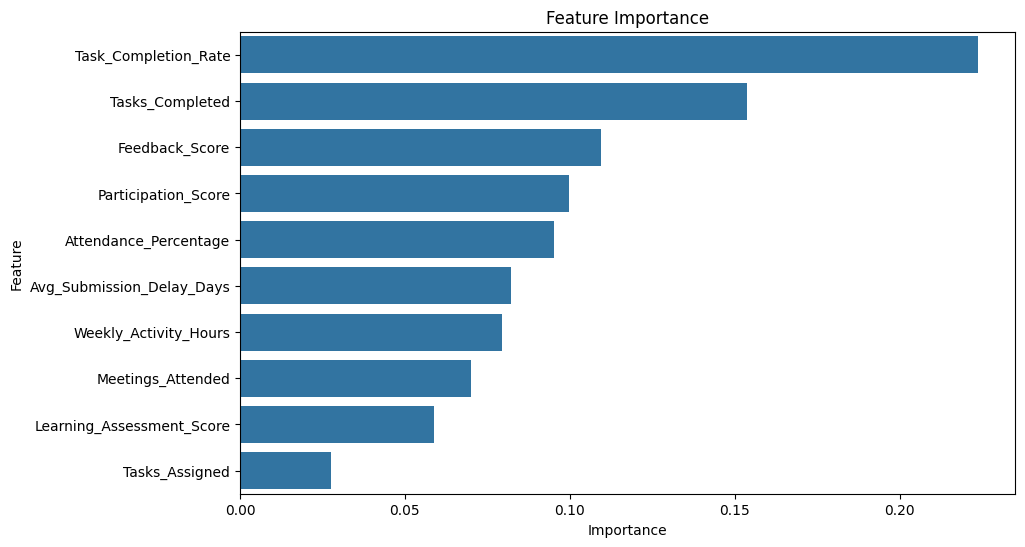

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [68]:
%pip install joblib
import joblib

joblib.dump(model, "intern_performance_model.pkl")

print("Model saved successfully!")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Model saved successfully!


In [69]:
new_intern = pd.DataFrame({
    "Attendance_Percentage": [92],
    "Tasks_Assigned": [25],
    "Feedback_Score": [9],
    "Participation_Score": [8.5],
    "Learning_Assessment_Score": [88],
    "Avg_Submission_Delay_Days": [1],
    "Weekly_Activity_Hours": [34],
    "Meetings_Attended": [17],
    "Tasks_Completed": [24],
    "Task_Completion_Rate": [0.96]
})

prediction = model.predict(new_intern)
probability = model.predict_proba(new_intern)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[0. 1.]]
